# Smart Agriculture Dashboard

Dataset yang digunakan adalah Smart Agriculture Dataset yang berisi data sensor
pertanian seperti kelembaban tanah (MOI), suhu (temp), dan kelembaban udara (humidity).

Dataset digunakan untuk memonitor kondisi lingkungan pertanian
dan menganalisis faktor yang mempengaruhi pertumbuhan tanaman.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from google.colab import files
uploaded = files.upload()

Saving Smart Agriculture.csv to Smart Agriculture (3).csv


In [18]:
df = pd.read_csv("Smart Agriculture.csv")
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [28]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


Dataset terdiri dari 16411 data dengan 7 atribut yaitu crop ID,
soil_type, Seedling Stage, MOI, temp, humidity, dan result.

Data disimpan dalam format CSV dan dimuat ke dalam DataFrame menggunakan Pandas.

In [20]:
df.isnull().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


In [21]:
df.dtypes

,0
crop ID,object
soil_type,object
Seedling Stage,object
MOI,int64
temp,int64
humidity,float64
result,int64


In [22]:
df.describe()

,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


In [23]:
print("Rata-rata suhu:", df["temp"].mean())
print("Rata-rata kelembaban:", df["humidity"].mean())
print("Rata-rata kelembaban tanah:", df["MOI"].mean())

Rata-rata suhu: 28.832612272256412
Rata-rata kelembaban: 63.487752117482174
Rata-rata kelembaban tanah: 43.695387240265674


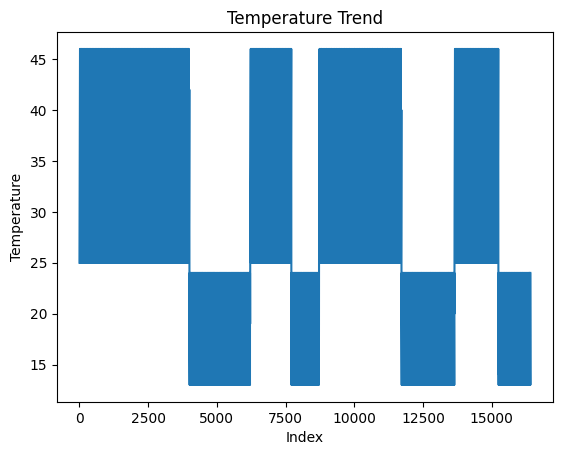

In [24]:
plt.figure()
plt.plot(df["temp"])
plt.title("Temperature Trend")
plt.xlabel("Index")
plt.ylabel("Temperature")
plt.show()

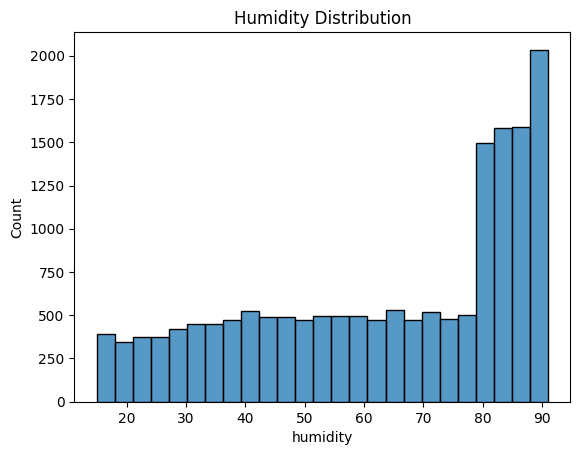

In [25]:
plt.figure()
sns.histplot(df["humidity"])
plt.title("Humidity Distribution")
plt.show()

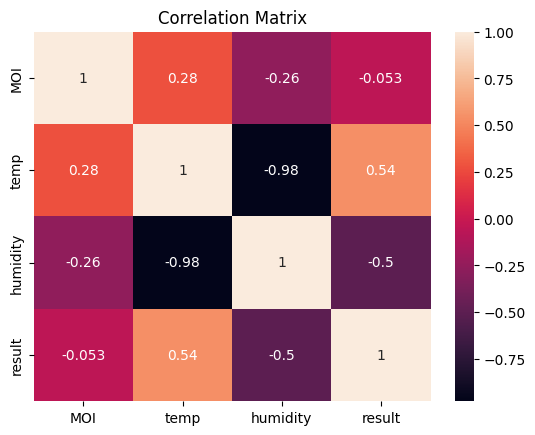

In [26]:
plt.figure()
sns.heatmap(df[['MOI','temp','humidity','result']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

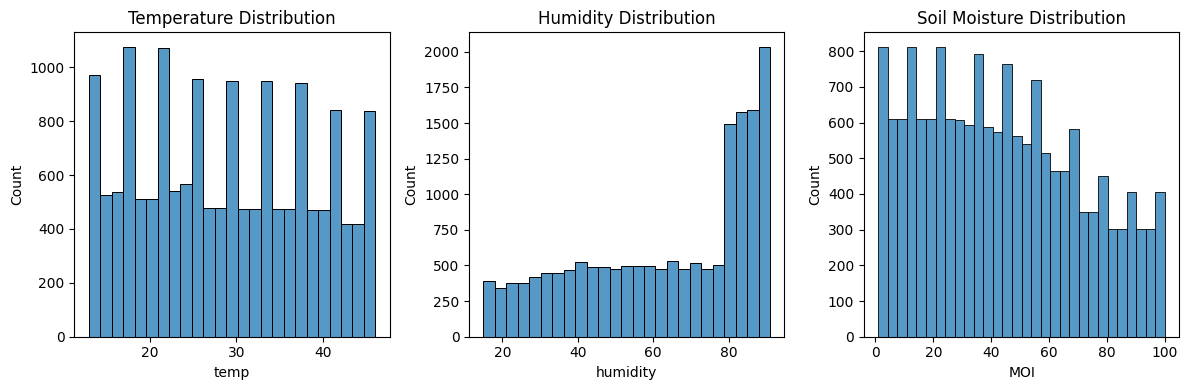

In [30]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(df['temp'])
plt.title("Temperature Distribution")

plt.subplot(1,3,2)
sns.histplot(df['humidity'])
plt.title("Humidity Distribution")

plt.subplot(1,3,3)
sns.histplot(df['MOI'])
plt.title("Soil Moisture Distribution")

plt.tight_layout()
plt.show()

Dashboard ini menampilkan kondisi sensor pertanian seperti suhu,
kelembaban udara, dan kelembaban tanah secara visual sehingga
petani dapat memonitor kondisi lingkungan tanaman.

Data governance dilakukan untuk memastikan kualitas data.

Accuracy
Data berasal dari sensor pertanian sehingga menggambarkan kondisi lingkungan sebenarnya.

Completeness
Dataset diperiksa untuk memastikan tidak ada missing value.

Consistency
Data memiliki format yang konsisten dan terstruktur.

Timeliness
Data sensor dapat diperbarui secara berkala untuk monitoring kondisi tanaman.

In [32]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.8 MB/s eta 0:00:00


In [34]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

report = SimpleDocTemplate("analysis_report.pdf")

content = []

content.append(Paragraph("Smart Agriculture Data Analysis Report", styles['Title']))
content.append(Spacer(1,20))

content.append(Paragraph("Dataset berisi data sensor pertanian seperti suhu, kelembaban udara, dan kelembaban tanah.", styles['BodyText']))
content.append(Spacer(1,10))

content.append(Paragraph(f"Jumlah data: {df.shape[0]}", styles['BodyText']))
content.append(Paragraph(f"Jumlah kolom: {df.shape[1]}", styles['BodyText']))

content.append(Spacer(1,20))

content.append(Paragraph("Rata-rata Sensor:", styles['Heading2']))
content.append(Paragraph(f"Temperature: {df['temp'].mean():.2f}", styles['BodyText']))
content.append(Paragraph(f"Humidity: {df['humidity'].mean():.2f}", styles['BodyText']))
content.append(Paragraph(f"Soil Moisture: {df['MOI'].mean():.2f}", styles['BodyText']))

report.build(content)

print("analysis_report.pdf berhasil dibuat")

analysis_report.pdf berhasil dibuat
